## Exploring the Bag-of-Words architecture

Bag of Words (BoW) is a Natural Language Processing technique that converts text into numerical vectors by counting the frequency of each word within a document. It simplifies text into a "bag" of individual words, completely disregarding their original order, grammar, and context. This approach allows machine learning algorithms to process raw text data for tasks like sentiment analysis and spam detection.

In [2]:
import nltk
nltk.download('stopwords')
nltk.download('wordnet')
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer 
from nltk.stem.snowball import SnowballStemmer
from nltk.stem.wordnet import WordNetLemmatizer
import pandas as pd
import re
import numpy as np

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/shekhabdullahayubi/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/shekhabdullahayubi/nltk_data...


#### Take in a list of sentences

In [16]:
sentences = ["We are learning about Natural Language Processing Here",
            "Natural Language Processing making computers comprehend language data",
            "The field of Natural Language Processing is evolving everyday"]

#### Create a Pandas Series of the object

In [17]:
corpus = pd.Series(sentences)
corpus

0    We are learning about Natural Language Process...
1    Natural Language Processing making computers c...
2    The field of Natural Language Processing is ev...
dtype: object

#### Data preprocessing

In [29]:
def text_clean(corpus, keep_list):
    '''
    Purpose : Function to keep only alphabets, digits and certain words (punctuations, qmarks, tabs etc. removed)
    
    Input : Takes a text corpus, 'corpus' to be cleaned along with a list of words, 'keep_list', which have to be retained
            even after the cleaning process
    
    Output : Returns the cleaned text corpus
    
    '''
    cleaned_corpus = pd.Series()
    for row in corpus:
        qs = []
        for word in row.split():
            if word not in keep_list:
                p1 = re.sub(pattern='[^a-zA-Z0-9]',repl=' ',string=word)
                p1 = p1.lower()
                qs.append(p1)
            else : 
                qs.append(word)
        cleaned_corpus = pd.concat([cleaned_corpus, pd.Series([' '.join(qs)])], ignore_index=True)
        # cleaned_corpus = cleaned_corpus.append(pd.Series(' '.join(qs)))
    return cleaned_corpus

In [19]:
def stopwords_removal(corpus):
    wh_words = ['who', 'what', 'when', 'why', 'how', 'which', 'where', 'whom']
    stop = set(stopwords.words('english'))
    for word in wh_words:
        stop.remove(word)
    corpus = [[x for x in x.split() if x not in stop] for x in corpus]
    return corpus

In [20]:
def lemmatize(corpus):
    lem = WordNetLemmatizer()
    corpus = [[lem.lemmatize(x, pos = 'v') for x in x] for x in corpus]
    return corpus

In [21]:
def stem(corpus, stem_type = None):
    if stem_type == 'snowball':
        stemmer = SnowballStemmer(language = 'english')
        corpus = [[stemmer.stem(x) for x in x] for x in corpus]
    else :
        stemmer = PorterStemmer()
        corpus = [[stemmer.stem(x) for x in x] for x in corpus]
    return corpus

In [22]:
def preprocess(corpus, keep_list, cleaning = True, stemming = False, stem_type = None, lemmatization = False, remove_stopwords = True):
    '''
    Purpose : Function to perform all pre-processing tasks (cleaning, stemming, lemmatization, stopwords removal etc.)
    
    Input : 
    'corpus' - Text corpus on which pre-processing tasks will be performed
    'keep_list' - List of words to be retained during cleaning process
    'cleaning', 'stemming', 'lemmatization', 'remove_stopwords' - Boolean variables indicating whether a particular task should 
                                                                  be performed or not
    'stem_type' - Choose between Porter stemmer or Snowball(Porter2) stemmer. Default is "None", which corresponds to Porter
                  Stemmer. 'snowball' corresponds to Snowball Stemmer
    
    Note : Either stemming or lemmatization should be used. There's no benefit of using both of them together
    
    Output : Returns the processed text corpus
    
    '''
    
    if cleaning == True:
        corpus = text_clean(corpus, keep_list)
    
    if remove_stopwords == True:
        corpus = stopwords_removal(corpus)
    else :
        corpus = [[x for x in x.split()] for x in corpus]
    
    if lemmatization == True:
        corpus = lemmatize(corpus)
        
        
    if stemming == True:
        corpus = stem(corpus, stem_type)
    
    corpus = [' '.join(x) for x in corpus]        

    return corpus

In [13]:
common_dot_words = ['U.S.', 'Mr.', 'Mrs.', 'D.C.']

In [30]:
# Preprocessing with Lemmatization here
preprocessed_corpus = preprocess(corpus, keep_list = common_dot_words, stemming = False, stem_type = None,
                                lemmatization = True, remove_stopwords = True)
preprocessed_corpus

['learn natural language process',
 'natural language process make computers comprehend language data',
 'field natural language process evolve everyday']

#### Building the vocabulary

In [31]:
set_of_words = set()
for sentence in preprocessed_corpus:
    for word in sentence.split():
        set_of_words.add(word)
vocab = list(set_of_words)
print(vocab)

['evolve', 'learn', 'computers', 'field', 'language', 'process', 'data', 'make', 'comprehend', 'everyday', 'natural']


#### Fetching the position of each word in the vocabulary

In [32]:
position = {}
for i, token in enumerate(vocab):
    position[token] = i
print(position)

{'evolve': 0, 'learn': 1, 'computers': 2, 'field': 3, 'language': 4, 'process': 5, 'data': 6, 'make': 7, 'comprehend': 8, 'everyday': 9, 'natural': 10}


#### Creating a matrix to hold the Bag of Words representation

In [36]:
bow_matrix = np.zeros((len(preprocessed_corpus), len(vocab)))
bow_matrix

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]])

In [34]:
for i, preprocessed_sentence in enumerate(preprocessed_corpus):
    for token in preprocessed_sentence.split():   
        bow_matrix[i][position[token]] = bow_matrix[i][position[token]] + 1

In [35]:
bow_matrix

array([[0., 1., 0., 0., 1., 1., 0., 0., 0., 0., 1.],
       [0., 0., 1., 0., 2., 1., 1., 1., 1., 0., 1.],
       [1., 0., 0., 1., 1., 1., 0., 0., 0., 1., 1.]])

### Inference
Taking example of column 2 in the bow_matrix, the values are 1, 2 and 1 respectively.

Column 2 caters to index 2 corresponding to the word language.

language occurs once, twice and again once in the the sentences 1, 2 and 3 respectively.


## CountVectorizer for Bag of Words Model

In [37]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer()
bow_matrix = vectorizer.fit_transform(preprocessed_corpus)

In [39]:
print(vectorizer.get_feature_names_out())

['comprehend' 'computers' 'data' 'everyday' 'evolve' 'field' 'language'
 'learn' 'make' 'natural' 'process']


In [40]:
print(bow_matrix.toarray())

[[0 0 0 0 0 0 1 1 0 1 1]
 [1 1 1 0 0 0 2 0 1 1 1]
 [0 0 0 1 1 1 1 0 0 1 1]]


In [41]:
bow_matrix.toarray().shape

(3, 11)

The matrix is the same as what was obtained in previous section.

#### Prebuilt dictionary and support for n-grams

In [42]:
vectorizer_ngram_range = CountVectorizer(analyzer='word', ngram_range=(1,3))
bow_matrix_ngram = vectorizer_ngram_range.fit_transform(preprocessed_corpus)

In [43]:
vectorizer_ngram_range.get_feature_names_out()

array(['comprehend', 'comprehend language', 'comprehend language data',
       'computers', 'computers comprehend',
       'computers comprehend language', 'data', 'everyday', 'evolve',
       'evolve everyday', 'field', 'field natural',
       'field natural language', 'language', 'language data',
       'language process', 'language process evolve',
       'language process make', 'learn', 'learn natural',
       'learn natural language', 'make', 'make computers',
       'make computers comprehend', 'natural', 'natural language',
       'natural language process', 'process', 'process evolve',
       'process evolve everyday', 'process make',
       'process make computers'], dtype=object)

In [44]:
bow_matrix_ngram.toarray()

array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0,
        0, 0, 1, 1, 1, 1, 0, 0, 0, 0],
       [1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 2, 1, 1, 0, 1, 0, 0, 0, 1,
        1, 1, 1, 1, 1, 1, 0, 0, 1, 1],
       [0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0,
        0, 0, 1, 1, 1, 1, 1, 1, 0, 0]])

#### Inference
As can be seen, the 9th phrase from the end natural language process occurs once in every sentence.

The column corresponding to it has the entries 1, 1 and 1.

#### Understanding Max Features

In [45]:
vectorizer_max_features = CountVectorizer(analyzer='word', ngram_range=(1,3), max_features = 6)
bow_matrix_max_features = vectorizer_max_features.fit_transform(preprocessed_corpus)

In [46]:
vectorizer_max_features.get_feature_names_out()

array(['language', 'language process', 'natural', 'natural language',
       'natural language process', 'process'], dtype=object)

In [47]:
bow_matrix_max_features.toarray()

array([[1, 1, 1, 1, 1, 1],
       [2, 1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1, 1]])

#### Inference
The Vocabulary and Bag of Words Model got limited to 6 features since max_features = 6 was provided as input to the CountVectorizer

#### Thresholding using Max_df and Min_df

In [48]:
vectorizer_max_features = CountVectorizer(analyzer='word', ngram_range=(1,3), max_df = 3, min_df = 2)
bow_matrix_max_features = vectorizer_max_features.fit_transform(preprocessed_corpus)

In [49]:
vectorizer_max_features.get_feature_names_out()

array(['language', 'language process', 'natural', 'natural language',
       'natural language process', 'process'], dtype=object)

In [50]:
bow_matrix_max_features.toarray()

array([[1, 1, 1, 1, 1, 1],
       [2, 1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1, 1]])

#### Inference
Terms with max_df less than or equal to or less than 3 were only present in the vocabulary.

Note: max_features was not used here

### Limitations of the BoW representation

* The BoW model also intrinsically provides possibilities for eliminating or reducing the significance of tokens or phrases that occur very rarely. 
* These phrases might be present in a very small number of documents, but they can be very important in the representation of those documents. The BoW model does not support such possibilities.
* These models do not take into account semantics or meanings associated with a token or phrases in a document. It ignores the possibility of capturing features from the neighborhood of a phrase that can hint at the context in which a word or phrase is being used. Therefore, it completely ignores the context involved.

## TF-IDF vectors - 

The words that occur rarely are either removed or their weights are too low compared to words that occur very frequently. While following this kind of approach, the pattern of information carried across terms that are rarely present but carry a high amount of information for a document or an evident pattern across similar documents is lost. The TF-IDF approach for weighing terms in a text corpus helps mitigate this issue.

`TF-IDF` is also an occurrence-based method for vectorizing text and extracting features out of it. It is a composite of two terms, which are described as follows:
1. `__TF__` is similar to the CountVectorizer tool. It takes into account how frequently a term occurs in a document. Since most of the documents in a text corpus are of different lengths, it is very likely that a term would appear more frequently in longer documents rather than in smaller ones.This calls for normalizing the frequency of the term by dividing it with the count of the terms in the document. There are multiple variations to calculate TF, but the following is the most common representation:

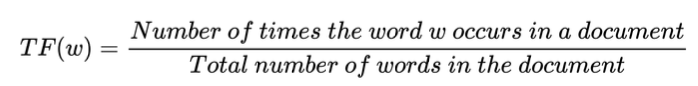

2. `__IDF__` is what does justice to terms that occur not so frequently across documents but might be more meaningful in representing the document. It measures the importance of a term in a document. The usage of TF only would provide more weightage to terms that occur very frequently. As part of IDF, just the opposite is done, whereby the weights of frequently occurring terms are suppressed and the weights of possibly more meaningful but less frequently occurring terms are scaled up. Similar to TF, there are multiple ways to measure IDF, but the following is the most common representation:

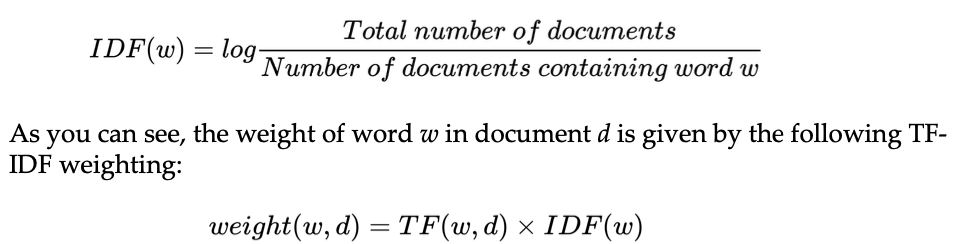

As can be seen, the weight of word w in document d is a product of the TF of word w in document d and the IDF of word w across the text corpus.

In [51]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()
tf_idf_matrix = vectorizer.fit_transform(preprocessed_corpus)

In [52]:
vectorizer.get_feature_names_out()

array(['comprehend', 'computers', 'data', 'everyday', 'evolve', 'field',
       'language', 'learn', 'make', 'natural', 'process'], dtype=object)

In [53]:
tf_idf_matrix.toarray()

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.41285857, 0.69903033, 0.        , 0.41285857,
        0.41285857],
       [0.40512186, 0.40512186, 0.40512186, 0.        , 0.        ,
        0.        , 0.478543  , 0.        , 0.40512186, 0.2392715 ,
        0.2392715 ],
       [0.        , 0.        , 0.        , 0.49711994, 0.49711994,
        0.49711994, 0.29360705, 0.        , 0.        , 0.29360705,
        0.29360705]])

In [54]:
f'Shape of TF-IDF matrix is {tf_idf_matrix.shape}'

'Shape of TF-IDF matrix is (3, 11)'

#### Changing the norm to l1, default option is l2 which was used above
Each output row will have unit norm, which can be one of

__l2__: Sum of squares of vector elements is 1.

__l1__: Sum of absolute values of vector elements is 1.

In [55]:
vectorizer_l1_norm = TfidfVectorizer(norm="l1")
tf_idf_matrix_l1_norm = vectorizer_l1_norm.fit_transform(preprocessed_corpus)

In [56]:
vectorizer_l1_norm.get_feature_names_out()

array(['comprehend', 'computers', 'data', 'everyday', 'evolve', 'field',
       'language', 'learn', 'make', 'natural', 'process'], dtype=object)

In [57]:
tf_idf_matrix_l1_norm.toarray()

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.21307663, 0.3607701 , 0.        , 0.21307663,
        0.21307663],
       [0.1571718 , 0.1571718 , 0.1571718 , 0.        , 0.        ,
        0.        , 0.1856564 , 0.        , 0.1571718 , 0.0928282 ,
        0.0928282 ],
       [0.        , 0.        , 0.        , 0.2095624 , 0.2095624 ,
        0.2095624 , 0.12377093, 0.        , 0.        , 0.12377093,
        0.12377093]])

In [58]:
f'The shape of the TF-IDF matrix L1 norm is: {tf_idf_matrix_l1_norm.shape}'

'The shape of the TF-IDF matrix L1 norm is: (3, 11)'

## N-grams and Max features with TfidfVectorizer

In [59]:
vectorizer_n_gram_max_features = TfidfVectorizer(norm="l2", analyzer='word', ngram_range=(1,3), max_features = 6)
tf_idf_matrix_n_gram_max_features = vectorizer_n_gram_max_features.fit_transform(preprocessed_corpus)

In [62]:
print(vectorizer_n_gram_max_features.get_feature_names_out())
print(tf_idf_matrix_n_gram_max_features.toarray())
print("\nThe shape of the TF-IDF matrix l2 norm is: ", tf_idf_matrix_n_gram_max_features.shape)

['language' 'language process' 'natural' 'natural language'
 'natural language process' 'process']
[[0.40824829 0.40824829 0.40824829 0.40824829 0.40824829 0.40824829]
 [0.66666667 0.33333333 0.33333333 0.33333333 0.33333333 0.33333333]
 [0.40824829 0.40824829 0.40824829 0.40824829 0.40824829 0.40824829]]

The shape of the TF-IDF matrix l2 norm is:  (3, 6)


#### Limitation of TF-IDF vectorizer representation :

The TF-IDF vectorizer offers an improvement over CountVectorizer by scaling the weights of the less frequently occurring terms as well as by using the IDF component. It is also computationally fast. However, it still relies on lexical analysis and does not take into account things such as the co-occurrence of terms, semantics, the context associated with terms, and the position of a term in a document. 

It is dependent on the vocabulary size, like CountVectorizer, and will get really slow with large vocabulary sizes.


## Distance/similarity calculation between document vectors

If the words being used in two documents are similar, it indicates that the documents are similar as well.

## Cosine similarity

Cosine similarity provides insights into the angle between two vectors. Two vectors would be similar if they are pretty close in terms of both direction and magnitude.

Cosine similarity helps in measuring the cosine of the angles between two vectors. The value of cosine similarity would lie in the range -1 to +1. The value +1 indicates that the vectors are perfectly similar, and the value -1 indicates that the vectors are perfectly dissimilar or exactly opposite to each other.

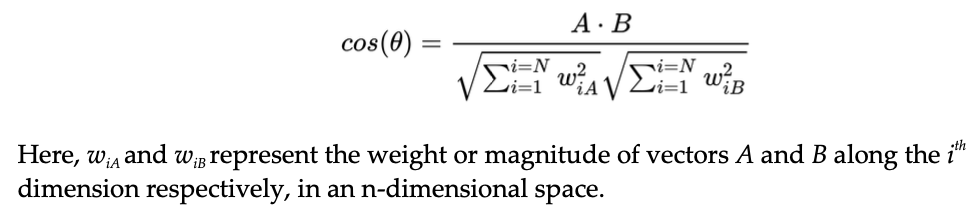

In [63]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

#### Cosine Similarity Calculation

In [64]:
def cosine_similarity(vector1, vector2):
    vector1 = np.array(vector1)
    vector2 = np.array(vector2)
    return np.dot(vector1, vector2) / (np.sqrt(np.sum(vector1**2)) * np.sqrt(np.sum(vector2**2)))

#### CountVectorizer

In [65]:
vectorizer = CountVectorizer()
bow_matrix = vectorizer.fit_transform(preprocessed_corpus)

In [67]:
print(vectorizer.get_feature_names_out())
print(bow_matrix.toarray())

['comprehend' 'computers' 'data' 'everyday' 'evolve' 'field' 'language'
 'learn' 'make' 'natural' 'process']
[[0 0 0 0 0 0 1 1 0 1 1]
 [1 1 1 0 0 0 2 0 1 1 1]
 [0 0 0 1 1 1 1 0 0 1 1]]


In [68]:
for i in range(bow_matrix.shape[0]):
    for j in range(i + 1, bow_matrix.shape[0]):
        print("The cosine similarity between the documents ", i, "and", j, "is: ",
              cosine_similarity(bow_matrix.toarray()[i], bow_matrix.toarray()[j]))

The cosine similarity between the documents  0 and 1 is:  0.6324555320336759
The cosine similarity between the documents  0 and 2 is:  0.6123724356957946
The cosine similarity between the documents  1 and 2 is:  0.5163977794943223


As can be noted from the cosine similarity calculations in the following output block, document 0 and document 1 are the closest or most similar, while document 1 and document 2 are the farthest or least similar.

#### TfidfVectorizer

In [70]:
vectorizer = TfidfVectorizer()
tf_idf_matrix = vectorizer.fit_transform(preprocessed_corpus)
print(vectorizer.get_feature_names_out())
print(tf_idf_matrix.toarray())
print("\nThe shape of the TF-IDF matrix is: ", tf_idf_matrix.shape)

['comprehend' 'computers' 'data' 'everyday' 'evolve' 'field' 'language'
 'learn' 'make' 'natural' 'process']
[[0.         0.         0.         0.         0.         0.
  0.41285857 0.69903033 0.         0.41285857 0.41285857]
 [0.40512186 0.40512186 0.40512186 0.         0.         0.
  0.478543   0.         0.40512186 0.2392715  0.2392715 ]
 [0.         0.         0.         0.49711994 0.49711994 0.49711994
  0.29360705 0.         0.         0.29360705 0.29360705]]

The shape of the TF-IDF matrix is:  (3, 11)


#### Cosine similarity between the document vectors built using TfidfVectorizer

In [71]:
for i in range(tf_idf_matrix.shape[0]):
    for j in range(i + 1, tf_idf_matrix.shape[0]):
        print("The cosine similarity between the documents ", i, "and", j, "is: ",
              cosine_similarity(tf_idf_matrix.toarray()[i], tf_idf_matrix.toarray()[j]))

The cosine similarity between the documents  0 and 1 is:  0.3951411576674912
The cosine similarity between the documents  0 and 2 is:  0.36365455673761865
The cosine similarity between the documents  1 and 2 is:  0.2810071916500233


output block, showing that document 0 and document 1 are the closest, and document 1 and document 2 are the farthest. However, the magnitudes here vary from what was obtained with CountVectorizer but the relative order of similarity remains the same

## One-hot vectorization

In general, a one-hot vector is used to represent categorical variables that take in values from a predefined list of values. These help in representing tokens as vectors that are required in certain use cases. In such vectors, all values are 0 except the one where the token is present, and this entry is marked 1.

For e.g. - the one-hot vectors would be as follows:\
   vec(hot)  = <0, 1>\
   vec(cold) = <1, 0>

#### Building the vocabulary

In [72]:
set_of_words = set()
for word in preprocessed_corpus[0].split():
    set_of_words.add(word)
vocab = list(set_of_words)
print(vocab)

['learn', 'natural', 'language', 'process']


#### Fetching the position of each word in the vocabulary

In [73]:
position = {}
for i, token in enumerate(vocab):
    position[token] = i
print(position)

{'learn': 0, 'natural': 1, 'language': 2, 'process': 3}


#### Instantiating the one hot matrix
_Note: here every row in the matrix corresponds to the One Hot vector for an individual term_

In [74]:
one_hot_matrix = np.zeros((len(preprocessed_corpus[0].split()), len(vocab)))
one_hot_matrix.shape

(4, 4)

#### Building One Hot Vectors

In [75]:
for i, token in enumerate(preprocessed_corpus[0].split()):
    one_hot_matrix[i][position[token]] = 1

one_hot_matrix

array([[1., 0., 0., 0.],
       [0., 1., 0., 0.],
       [0., 0., 1., 0.],
       [0., 0., 0., 1.]])

__Inference__

The first row corresponds to the One Hot vector of read,

second for natural,

third for language and

the final one for process

based on their respective indices in the vocabulary